# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [15]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [9]:
# Check for missing values
mv = df.isnull()

# Display summary statistics
df.describe()



,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


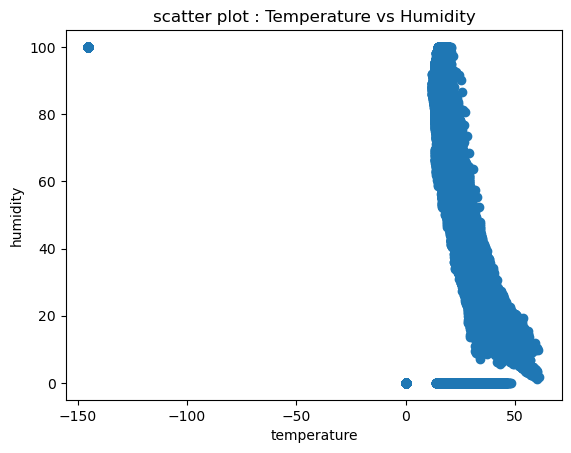

Correlation coefficient: -0.507828134348014


In [41]:
# Scatter plot to observe relationship
import numpy as np
x = df["temperature"]
y = df["humidity"]

plt.figure()
plt.scatter(x,y)

plt.xlabel("temperature")
plt.ylabel("humidity")
plt.title("scatter plot : Temperature vs Humidity" )
plt.show()

correlation = np.corrcoef(x, y)[0, 1]
print("Correlation coefficient:", correlation)

## Data Preprocessing

In [43]:
# Drop any rows with missing values
df.dropna()


# Define features and target
X = df[["temperature"]]   
y = df["humidity"]        

print("Feature (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

# Train-test split
X = df[["temperature"]]   
y = df["humidity"]        

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42       # For reproducibility
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Feature (X):
   temperature
0        23.46
1        23.06
2        26.53
3        28.34
4        26.31

Target (y):
0    62.48
1    59.46
2    44.38
3    38.28
4    46.37
Name: humidity, dtype: float64
Training data shape: (561238, 1)
Testing data shape: (140310, 1)


## Model Training

In [45]:
# Linear Regression
X = df[["temperature"]]   # Feature
y = df["humidity"]        # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Intercept:", model.intercept_)
print("Slope (Coefficient):", model.coef_[0])
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))





Intercept: 67.06471123177113
Slope (Coefficient): -0.7563883933919088
Mean Squared Error: 326.18280551077135
R2 Score: 0.2570619334024804


## Evaluation


In [49]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions (if not already done)
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


Model Performance:
Mean Absolute Error (MAE): 13.511099680961287
Mean Squared Error (MSE): 326.18280551077135
Root Mean Squared Error (RMSE): 18.060531706203207
R2 Score: 0.2570619334024804


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.
